In [4]:
from pathlib import Path
from typing import List

import pandas as pd
from Pipeline.Global.Plotting import Plotting

In [5]:
def process_and_calculate_rigorous(folder_path: str) -> pd.DataFrame:
    final_info: List[pd.DataFrame] = []
    trace_dir = Path(folder_path)

    for file_path in trace_dir.glob("*.csv"):
        df_trace = pd.read_csv(file_path)
        if df_trace.empty:
            continue

        target_iteration = df_trace['Max_Iteration'].iloc[0]
        df_converged = df_trace[df_trace['Iteration'] == target_iteration].copy()

        df_seed_agg = df_converged.groupby('Seed').agg(
            Train_Fit_Mean_by_Fold=('Train_Fitness', 'mean'),
            Train_Fit_Std_by_Fold=('Train_Fitness', 'std'),
            Val_Fit_Mean_by_Fold=('Val_Fitness', 'mean'),
            Val_Fit_Std_by_Fold=('Val_Fitness', 'std')
        ).fillna(0)

        # Intent: Compute Lower Confidence Bound (LCB) to penalize fold-level variance.
        df_seed_agg['Train_LCB'] = df_seed_agg['Train_Fit_Mean_by_Fold'] - df_seed_agg['Train_Fit_Std_by_Fold']
        df_seed_agg['Val_LCB'] = df_seed_agg['Val_Fit_Mean_by_Fold'] - df_seed_agg['Val_Fit_Std_by_Fold']

        record = {
            'expr_name': file_path.stem,
            'model_Train_Fit_Mean': df_seed_agg['Train_LCB'].mean(),
            'model_Train_Fit_Std': df_seed_agg['Train_LCB'].std(),
            'model_Val_Fit_Mean': df_seed_agg['Val_LCB'].mean(),
            'model_Val_Fit_Std': df_seed_agg['Val_LCB'].std()
        }

        record['final_train_trace'] = record['model_Train_Fit_Mean'] - record['model_Train_Fit_Std']
        record['final_val_trace'] = record['model_Val_Fit_Mean'] - record['model_Val_Fit_Std']

        final_info.append(pd.DataFrame([record]))

    return pd.concat(final_info, ignore_index=True) if final_info else pd.DataFrame()

In [6]:
df = process_and_calculate_rigorous('../Trace History')
df

,expr_name,model_Train_Fit_Mean,model_Train_Fit_Std,model_Val_Fit_Mean,model_Val_Fit_Std,final_train_trace,final_val_trace
0,cleaned_ABC_Convergence_Trace_100SN_50TL_100MI...,0.666579,0.009334,0.541681,0.040141,0.657245,0.501539
1,cleaned_ABC_Convergence_Trace_100SN_50TL_120MI...,0.670554,0.009846,0.567414,0.043257,0.660709,0.524157
2,cleaned_ABC_Convergence_Trace_10SN_5TL_1000MI_...,0.671924,0.012597,0.547316,0.048325,0.659327,0.498991
3,cleaned_ABC_Convergence_Trace_10SN_5TL_100MI_T...,0.610094,0.014522,0.550159,0.044745,0.595573,0.505414
4,cleaned_ABC_Convergence_Trace_10SN_5TL_150MI_T...,0.622371,0.010789,0.548253,0.046929,0.611583,0.501324
5,cleaned_ABC_Convergence_Trace_10SN_5TL_250MI_T...,0.636536,0.014298,0.552215,0.053748,0.622239,0.498467
6,cleaned_ABC_Convergence_Trace_10SN_5TL_500MI_T...,0.654987,0.013953,0.552283,0.042111,0.641034,0.510172
7,cleaned_ABC_Convergence_Trace_10SN_5TL_50MI_Trace,0.588731,0.012691,0.553680,0.045959,0.576040,0.507721
8,cleaned_ABC_Convergence_Trace_20SN_10TL_100MI_...,0.628181,0.013724,0.552627,0.051830,0.614458,0.500796
9,cleaned_ABC_Convergence_Trace_20SN_10TL_150MI_...,0.637823,0.012515,0.539645,0.044655,0.625308,0.494990


In [7]:
def process_and_plot_traces(folder_path: str):
    trace_dir = Path(folder_path)

    csv_files = list(trace_dir.glob("*.csv"))

    for file_path in csv_files:
        experiment_name = file_path.stem

        df_trace = pd.read_csv(file_path)
        if df_trace.empty:
            raise ValueError("CSV file is empty.")
        Plotting.plot_rigorous_convergence(
            df_trace_history=df_trace,
            experiment_name=experiment_name,
            is_final_record=True
        )

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_100SN_50TL_100MI_Trace_LCB_MCC.png


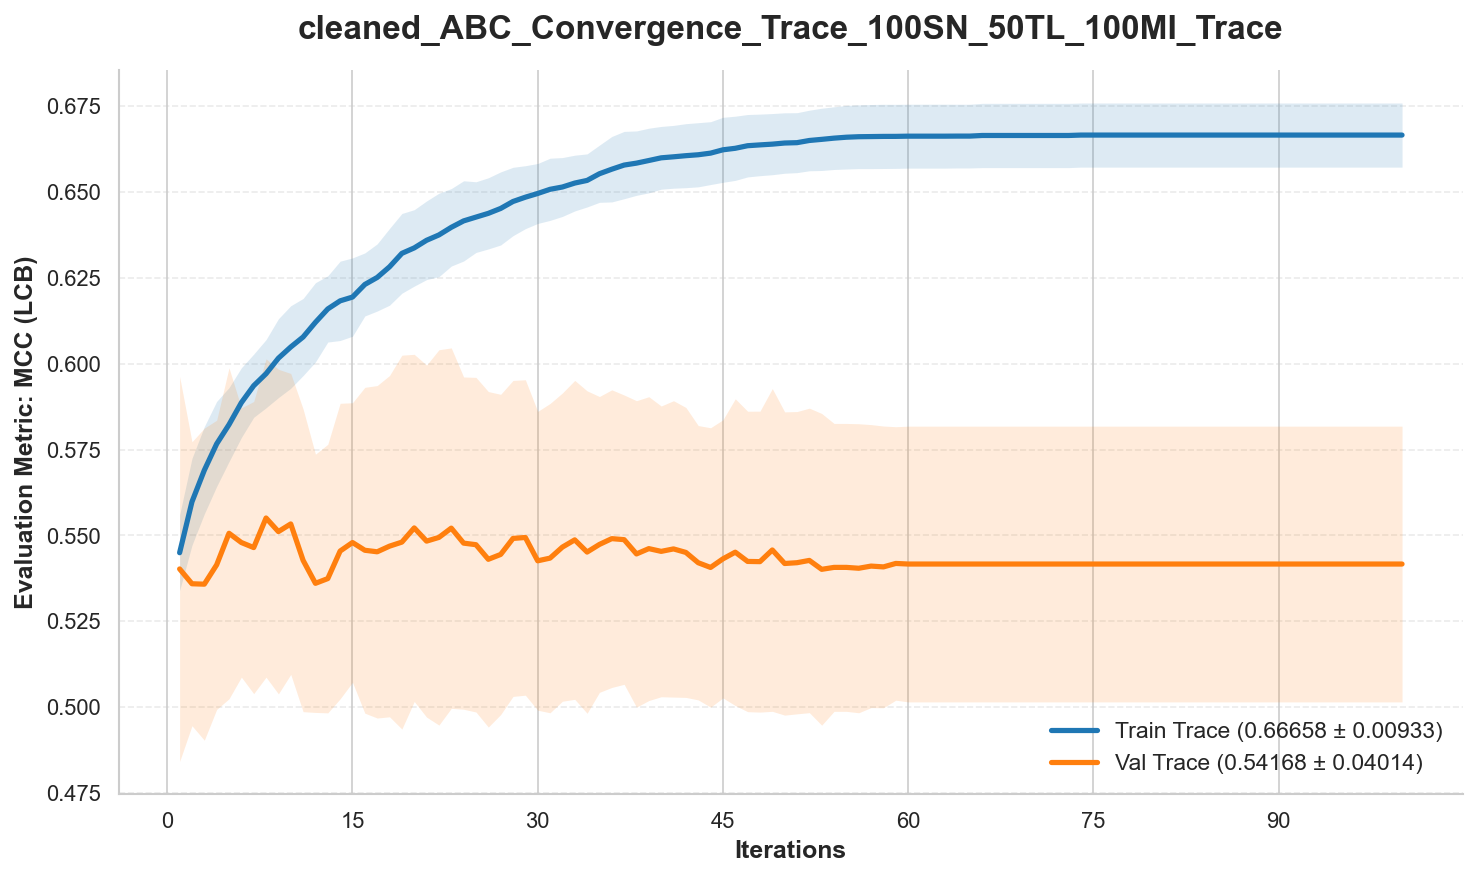

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_100SN_50TL_120MI_Trace_LCB_MCC.png


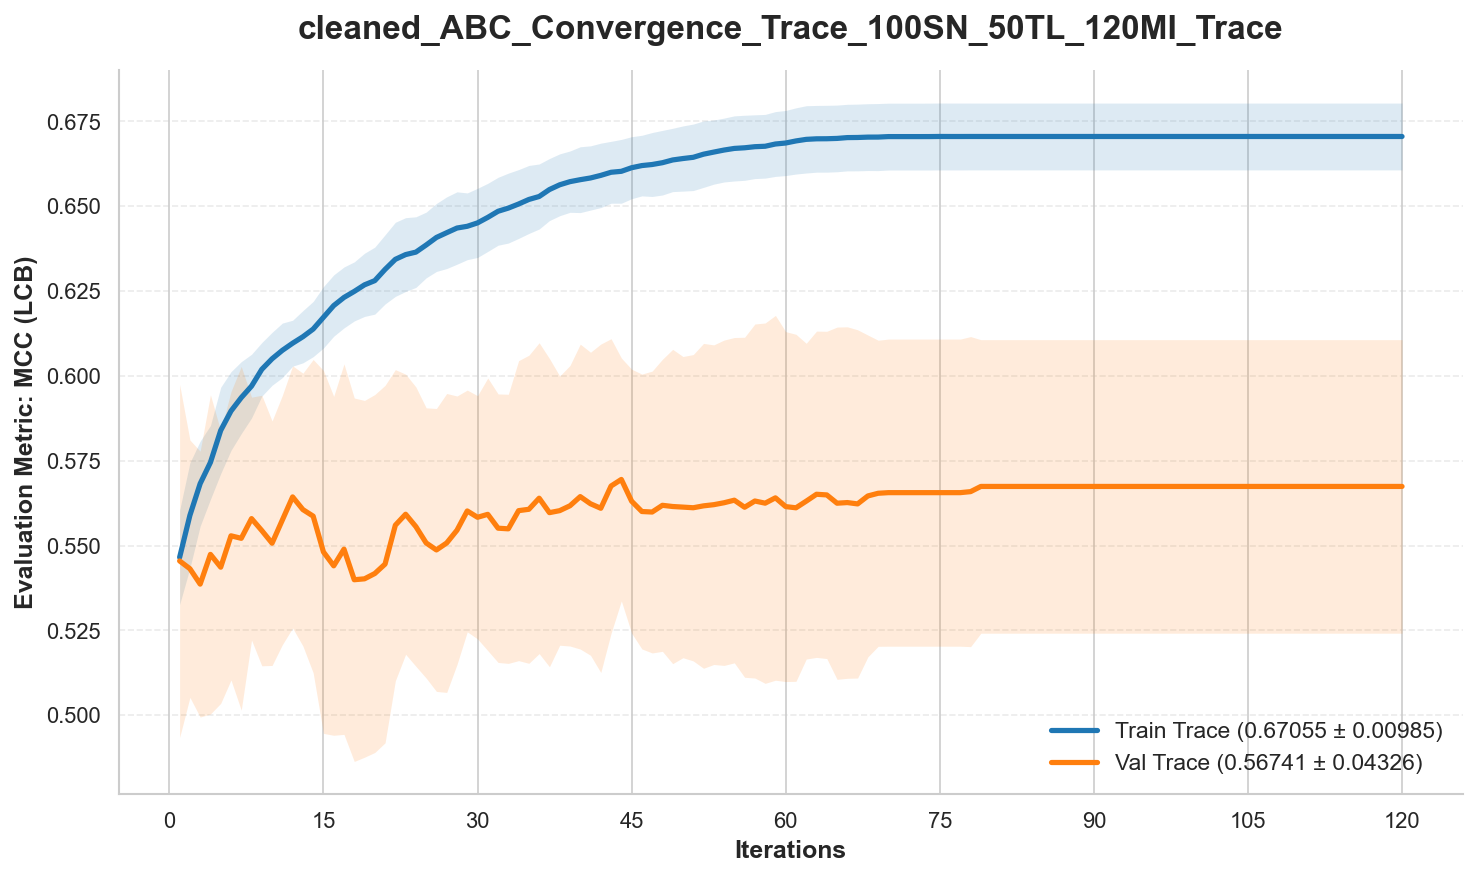

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_10SN_5TL_1000MI_Trace_LCB_MCC.png


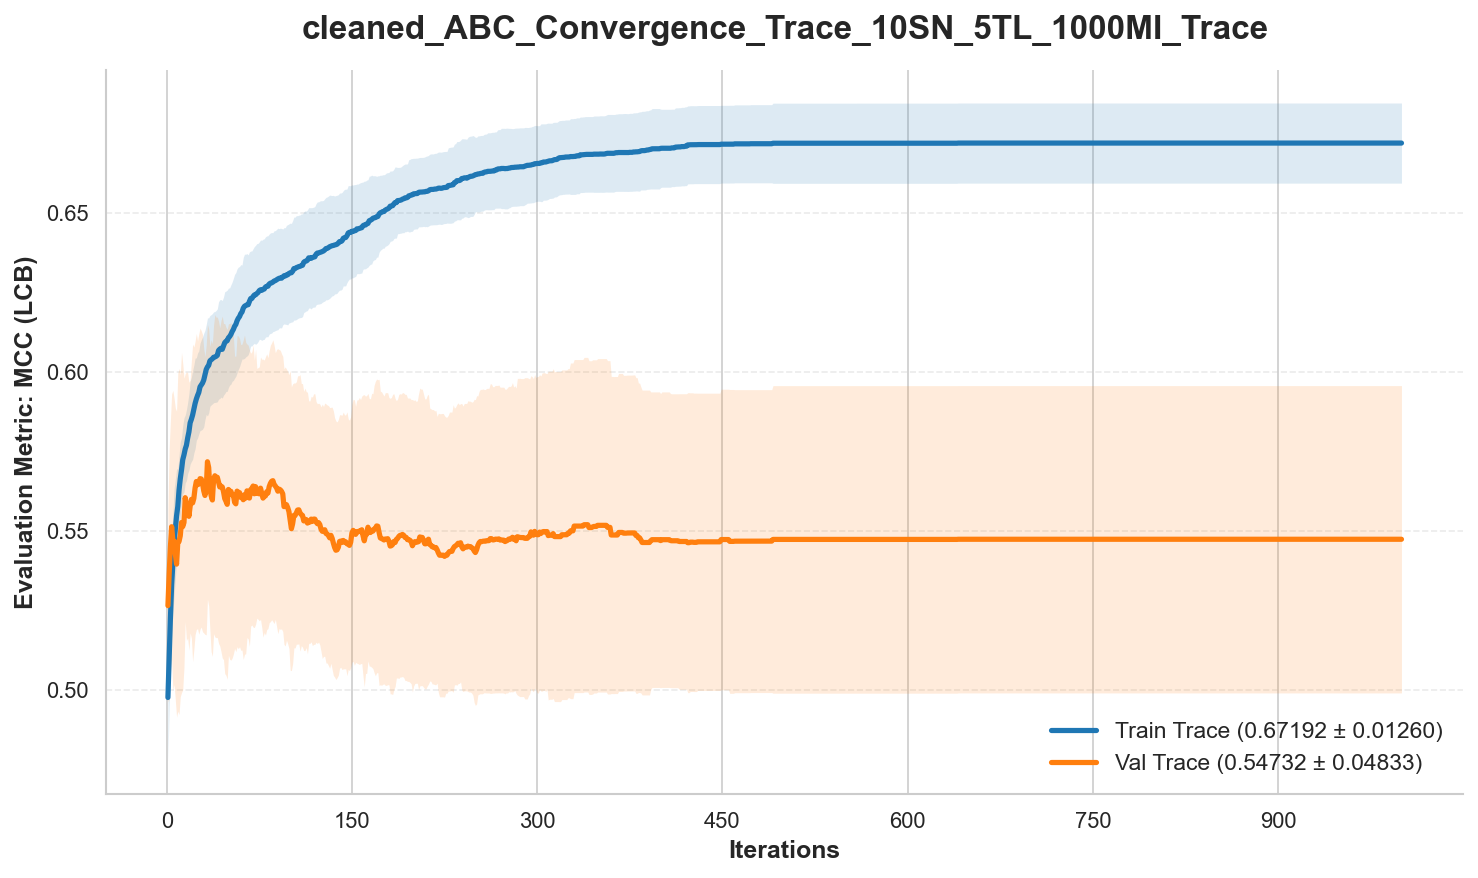

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_10SN_5TL_100MI_Trace_LCB_MCC.png


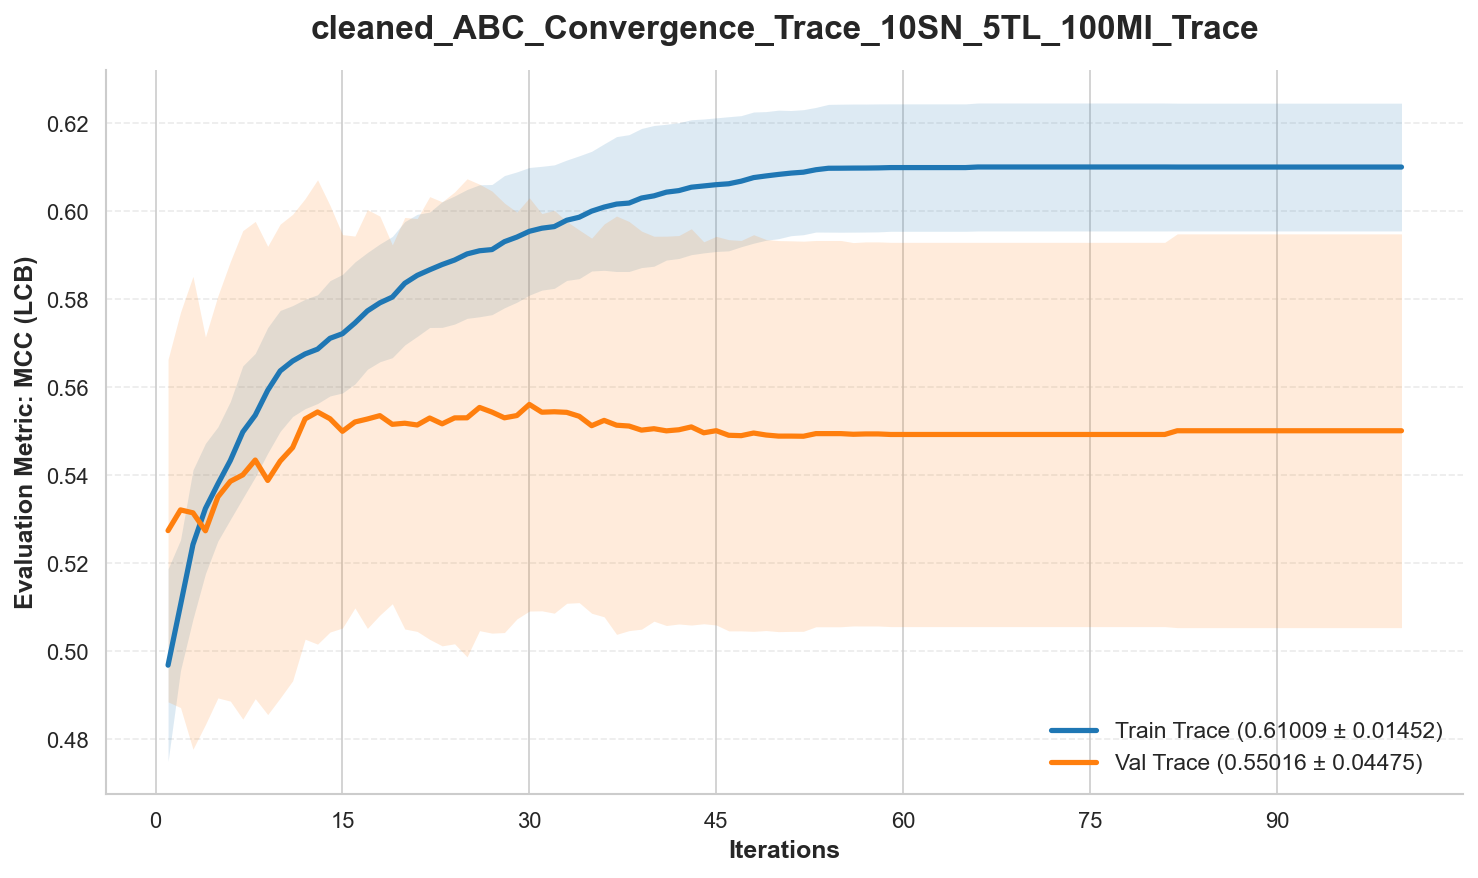

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_10SN_5TL_150MI_Trace_LCB_MCC.png


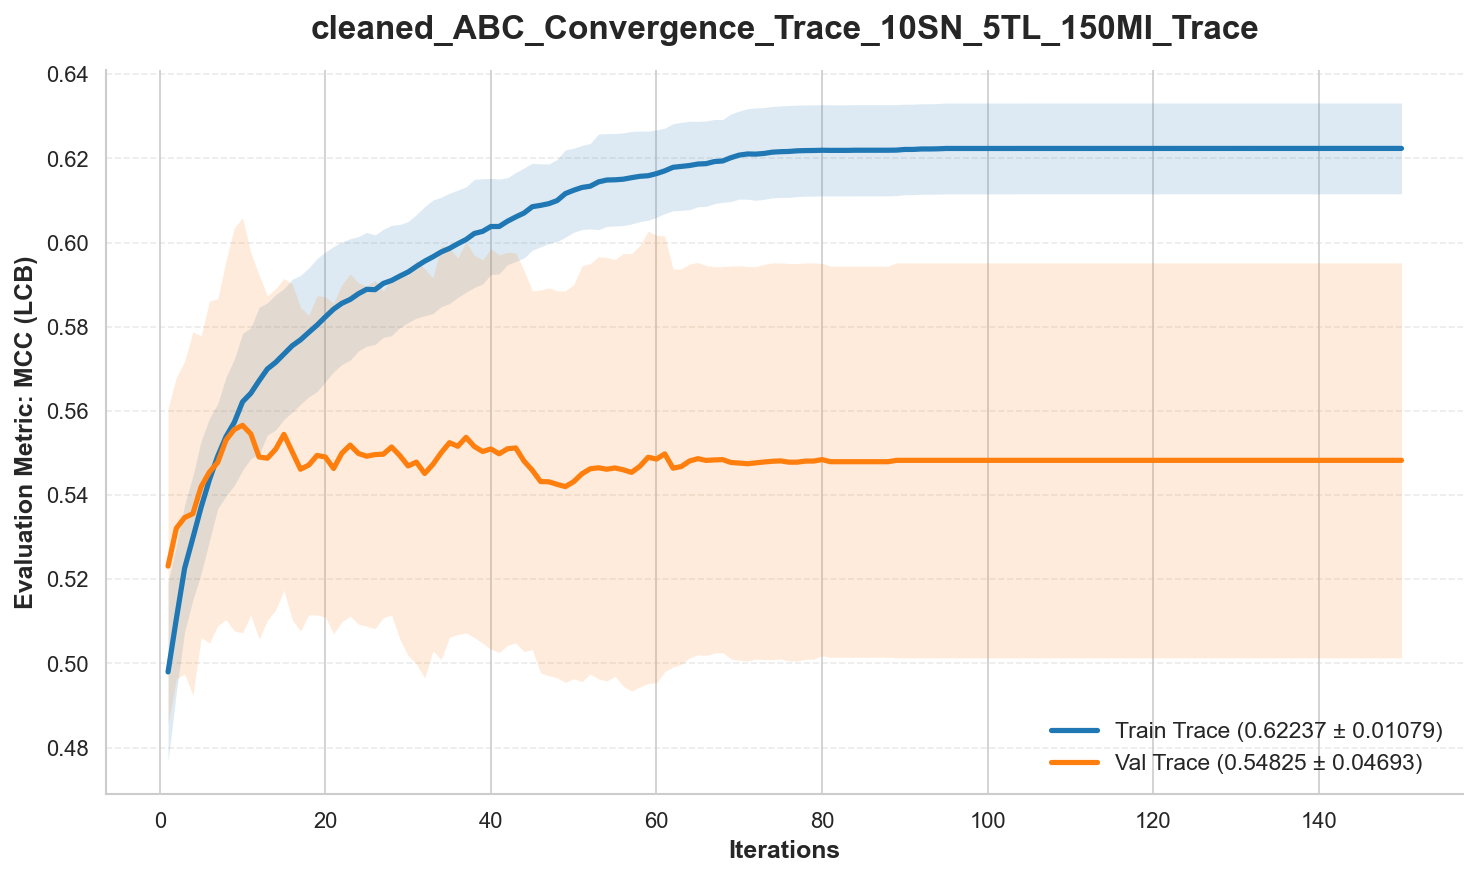

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_10SN_5TL_250MI_Trace_LCB_MCC.png


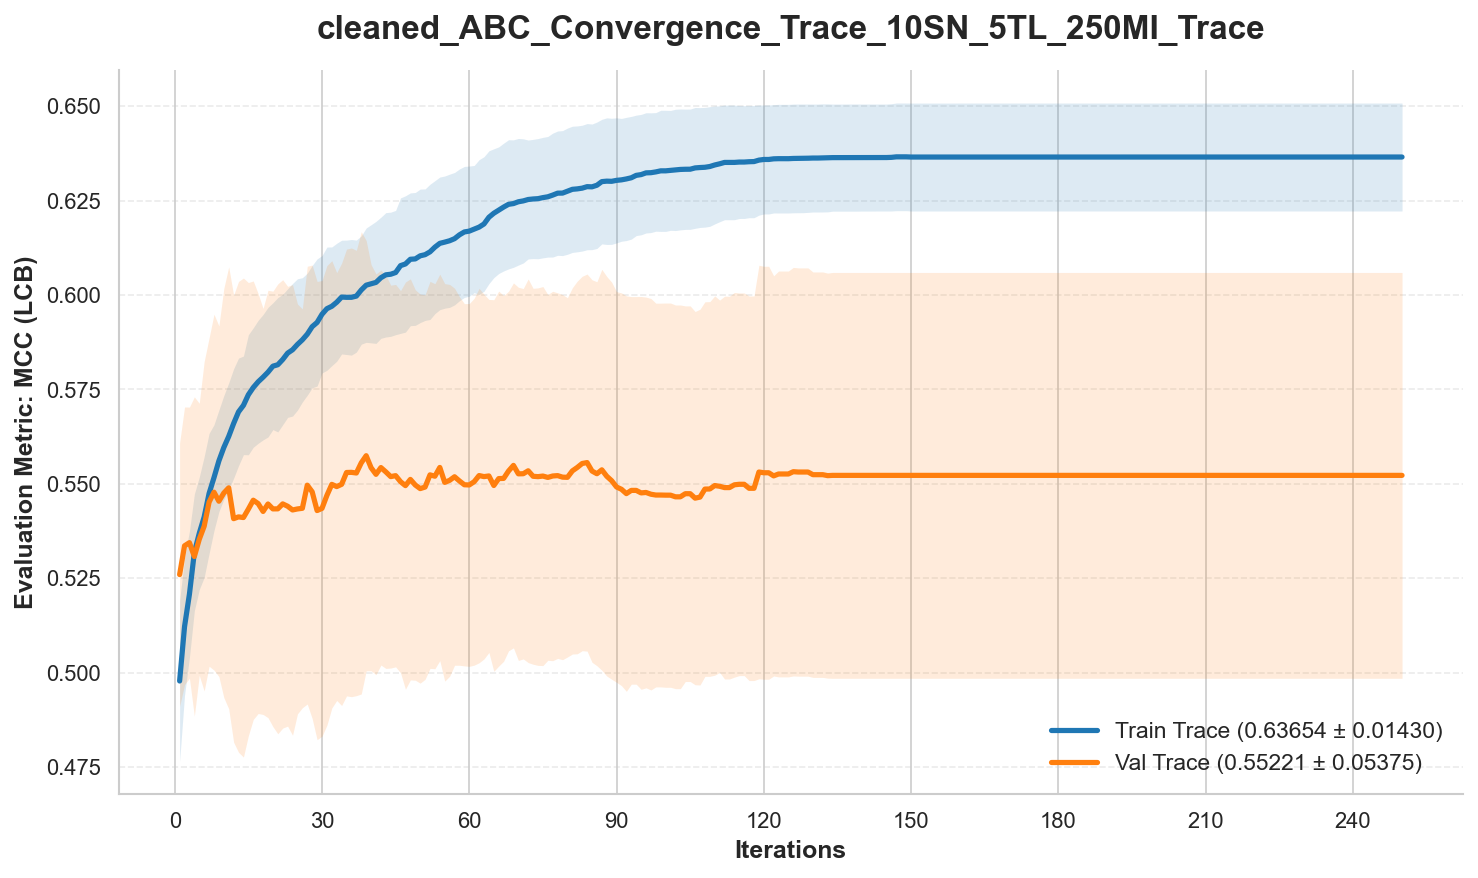

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_10SN_5TL_500MI_Trace_LCB_MCC.png


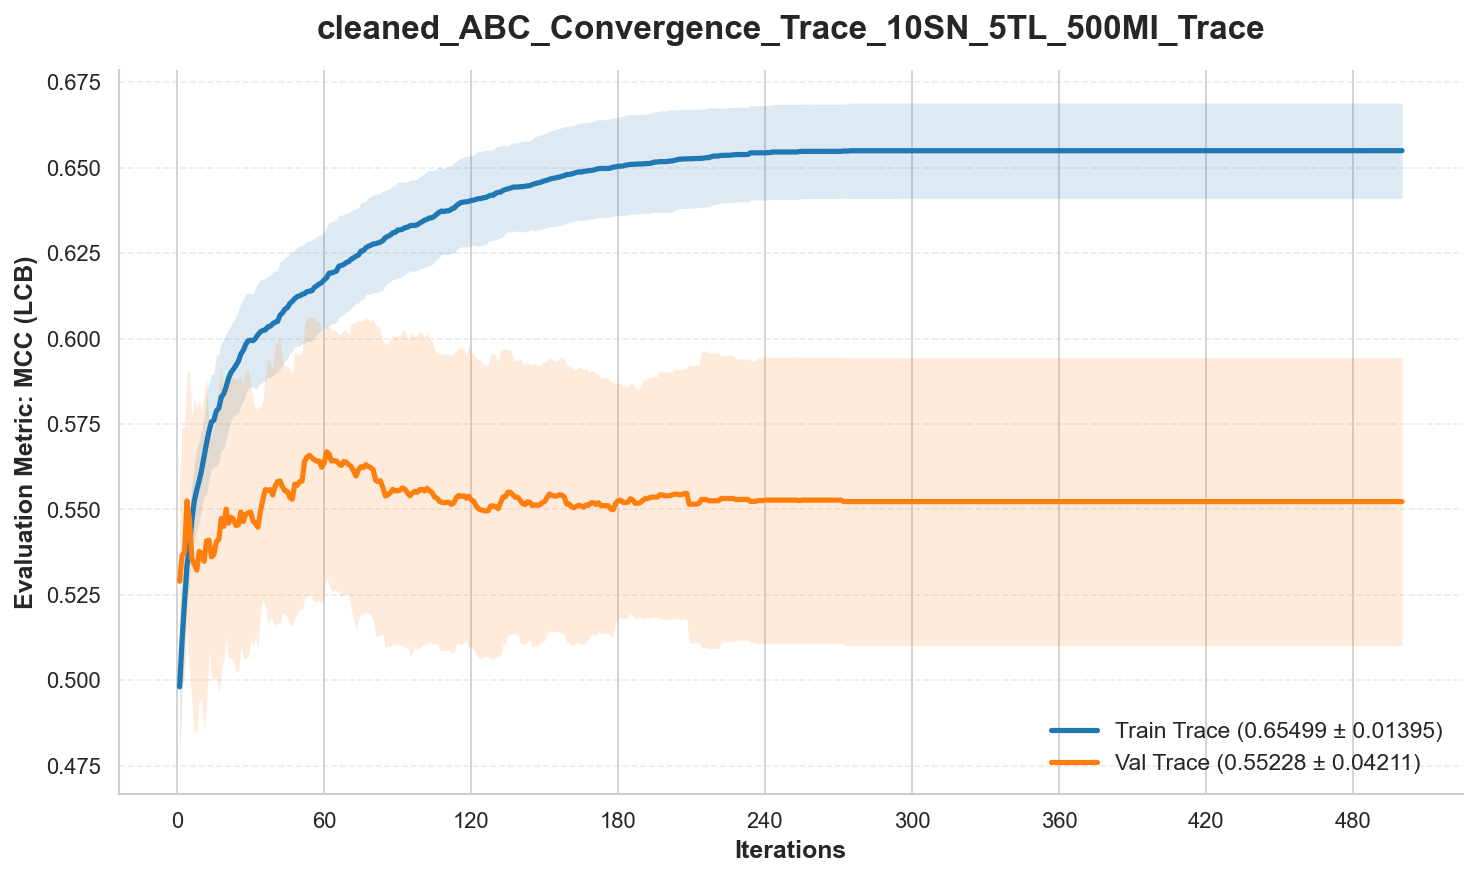

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_10SN_5TL_50MI_Trace_LCB_MCC.png


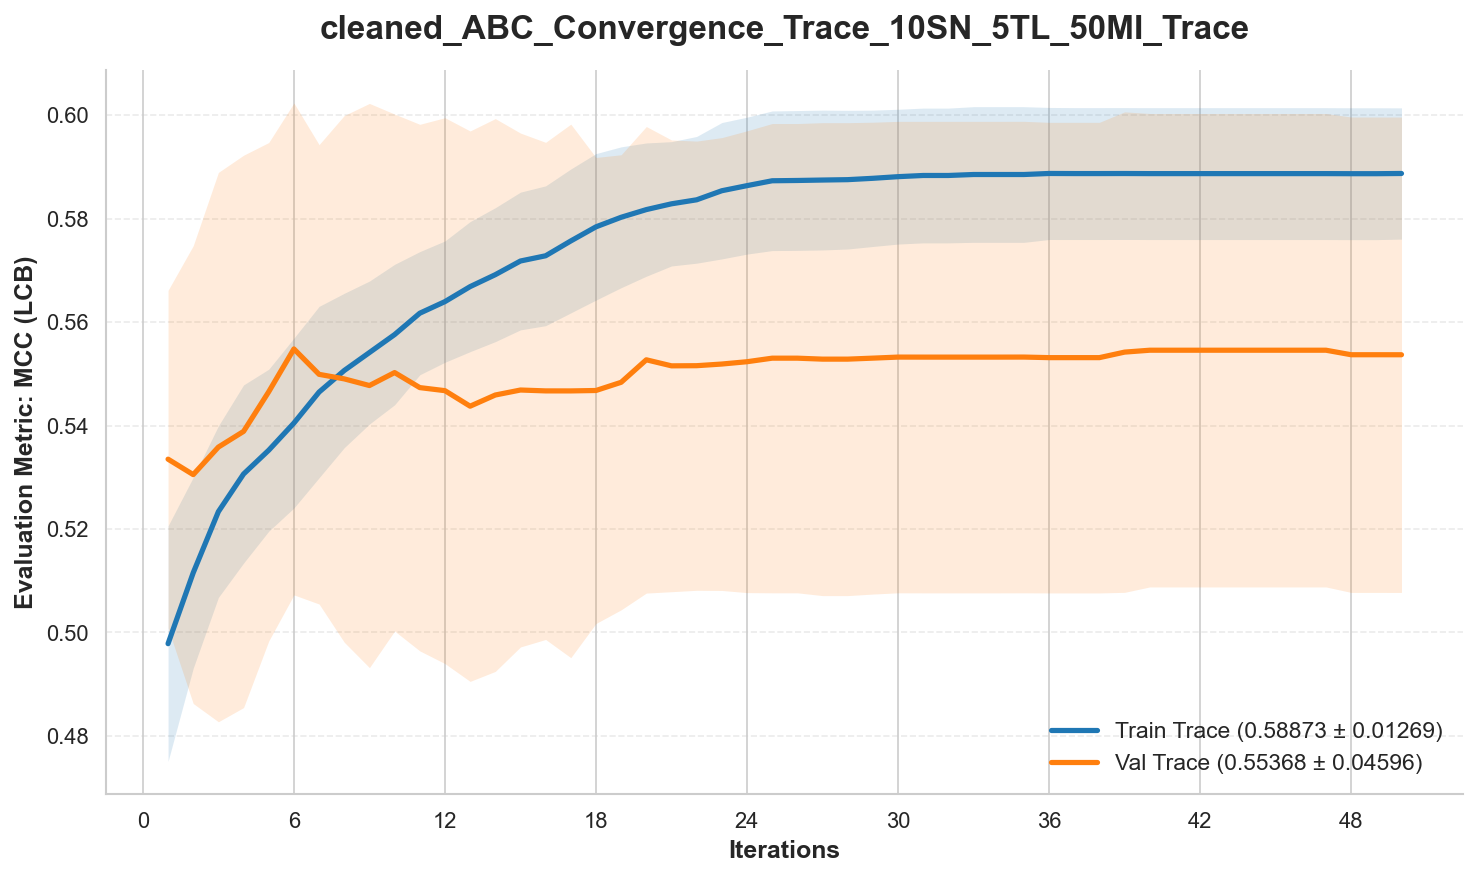

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_20SN_10TL_100MI_Trace_LCB_MCC.png


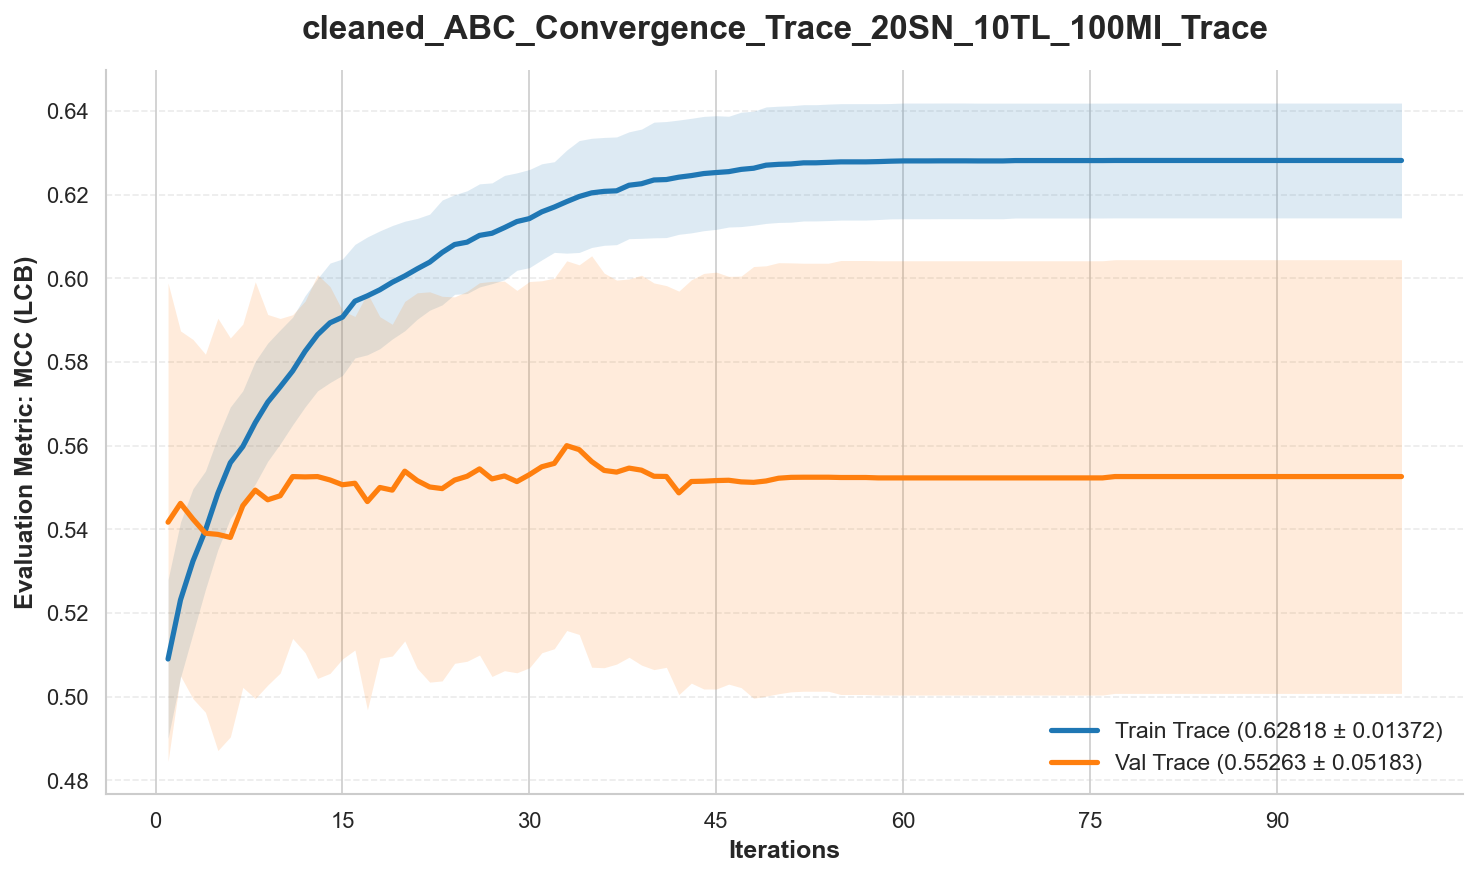

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_20SN_10TL_150MI_Trace_LCB_MCC.png


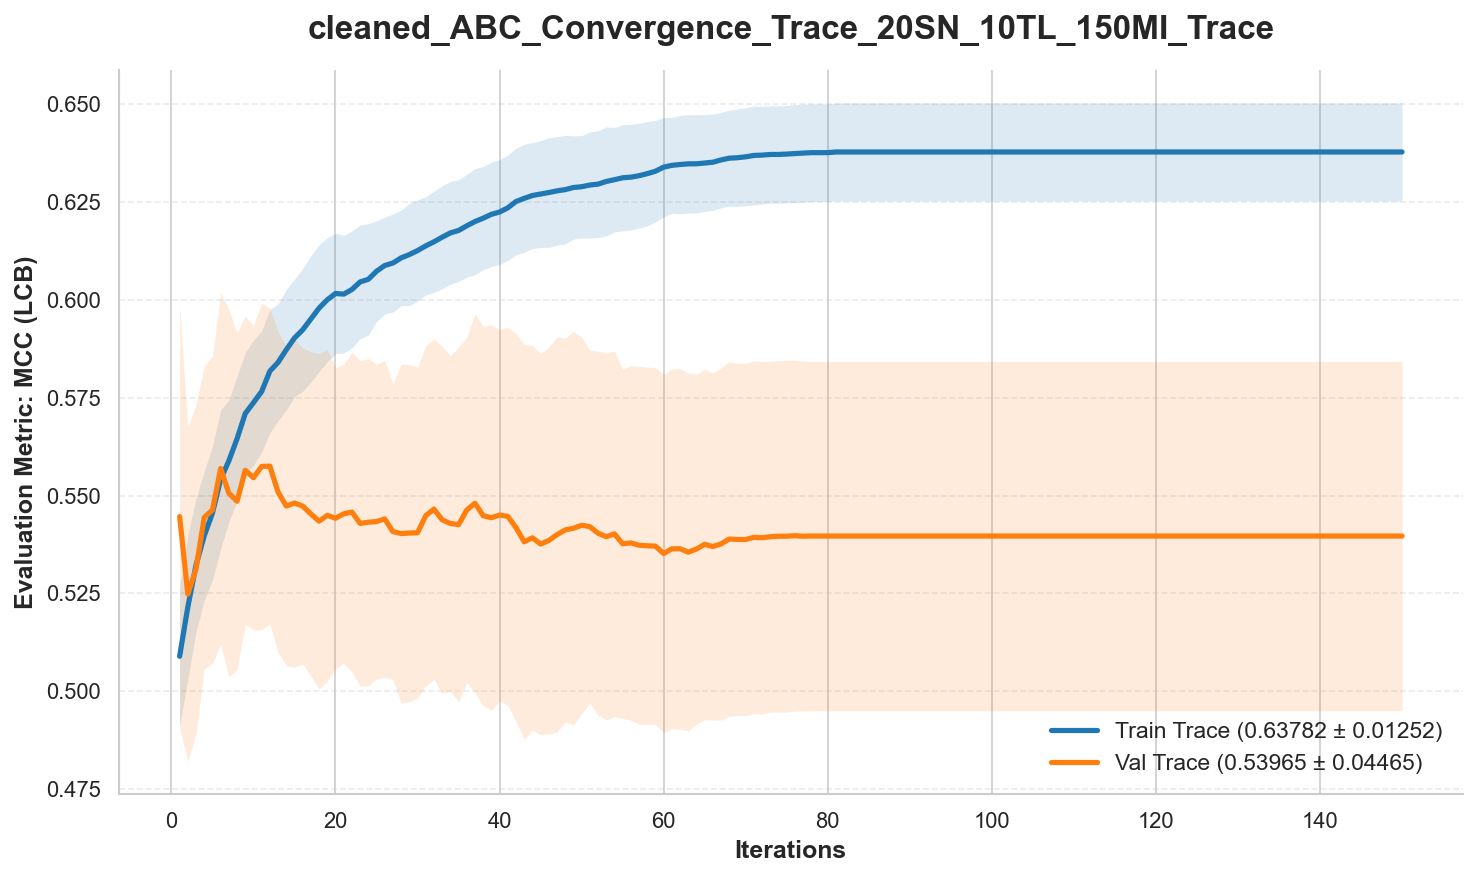

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_20SN_10TL_250MI_Trace_LCB_MCC.png


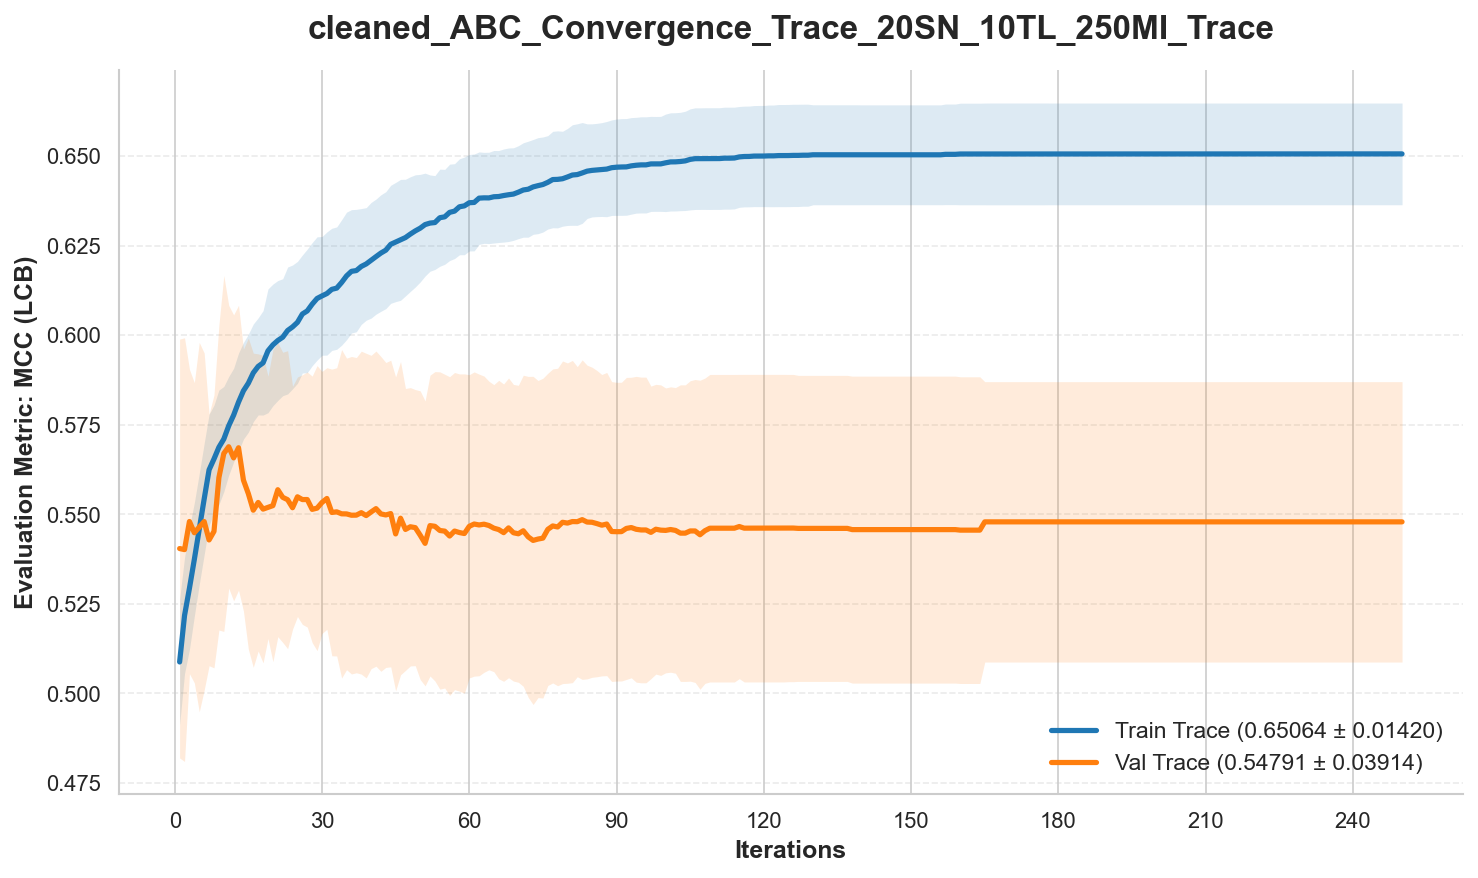

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_20SN_10TL_500MI_Trace_LCB_MCC.png


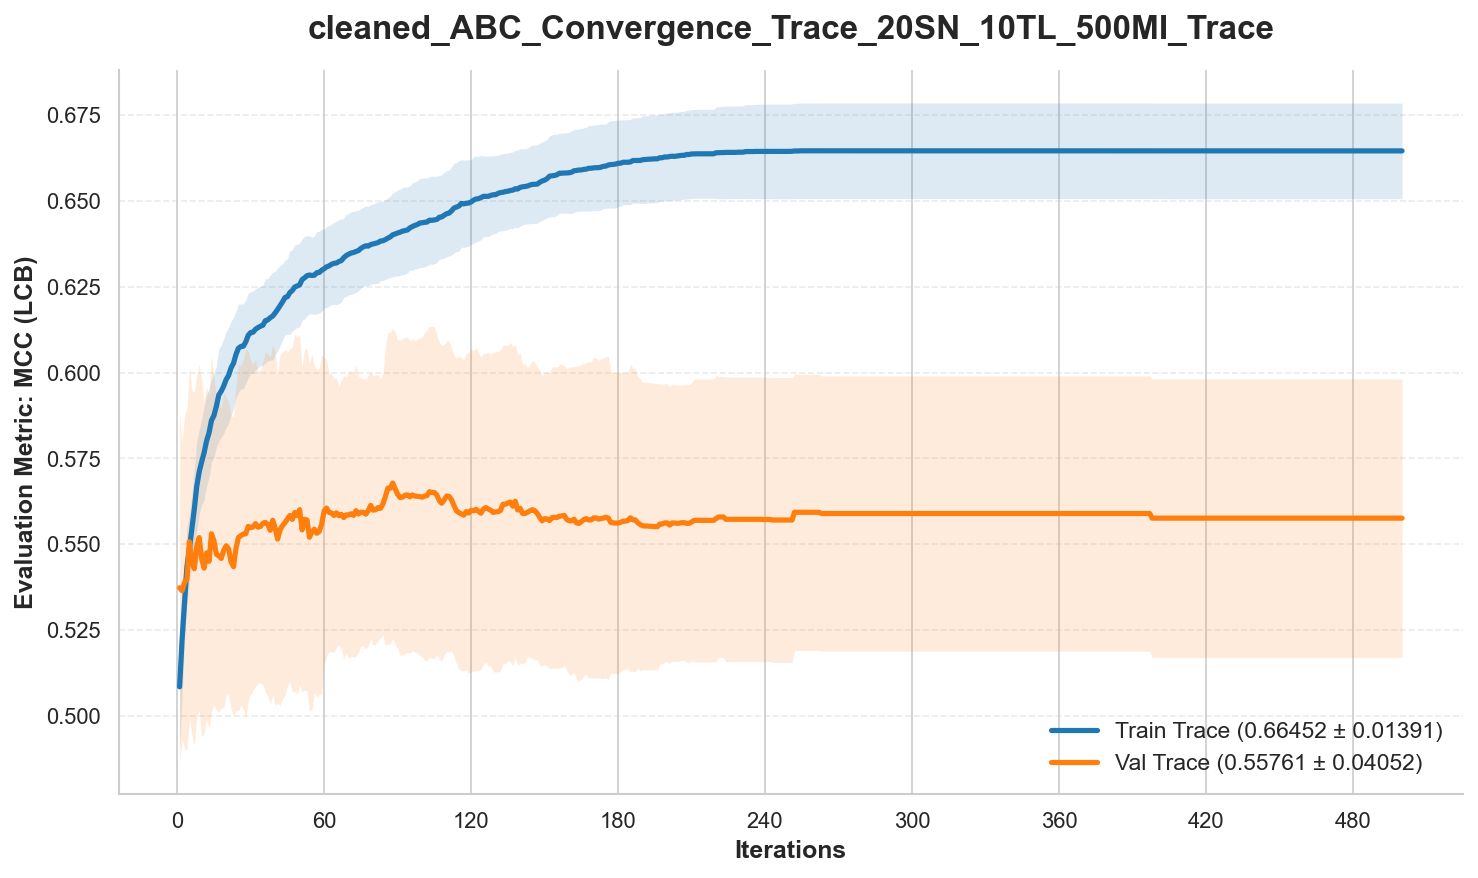

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_50SN_25TL_100MI_Trace_LCB_MCC.png


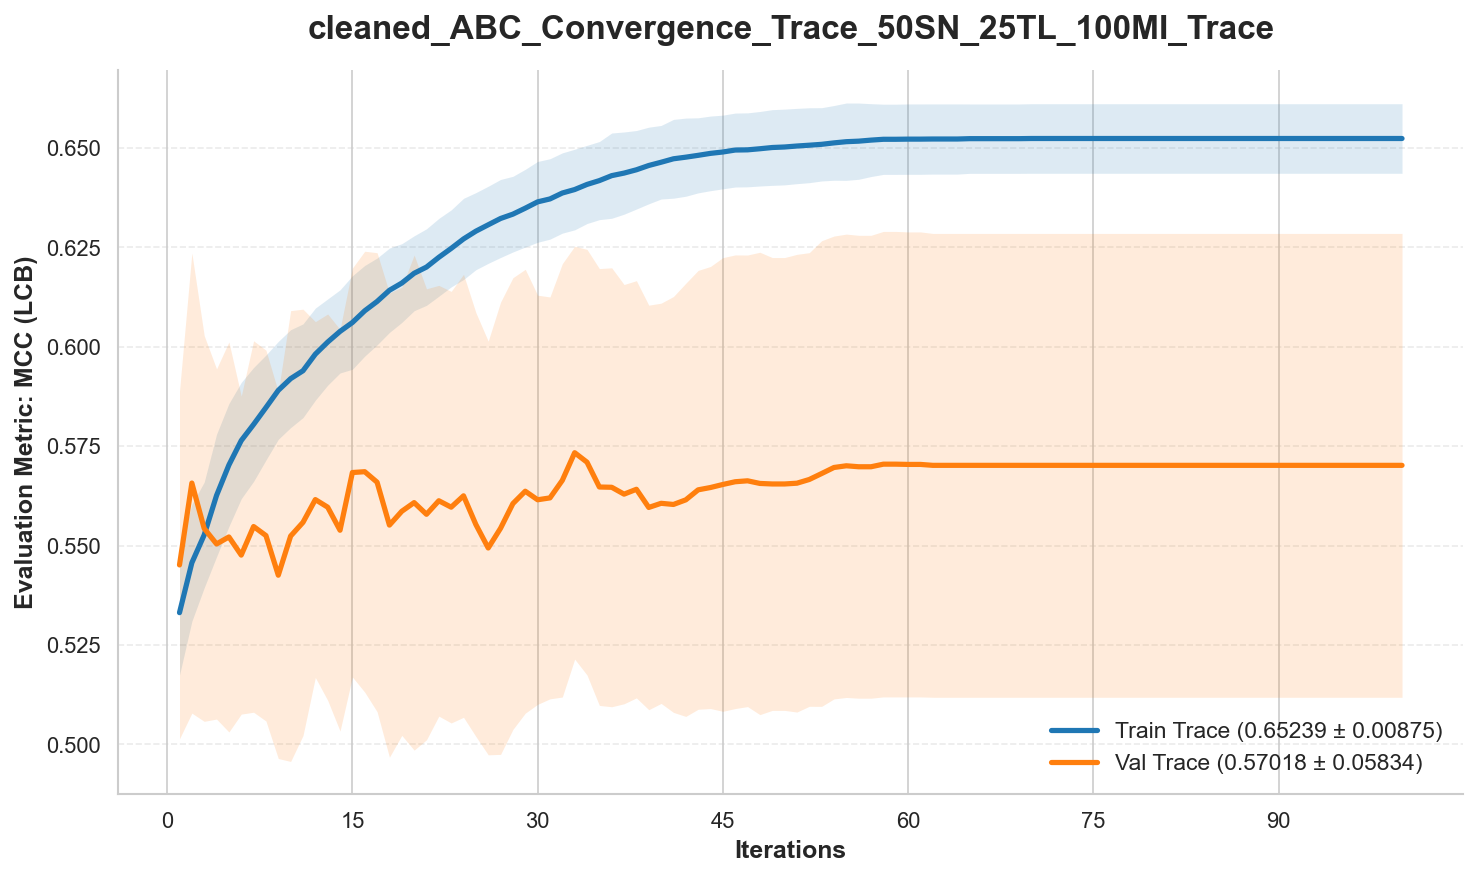

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Tuning Tracing/_cleaned_ABC_Convergence_Trace_50SN_25TL_150MI_Trace_LCB_MCC.png


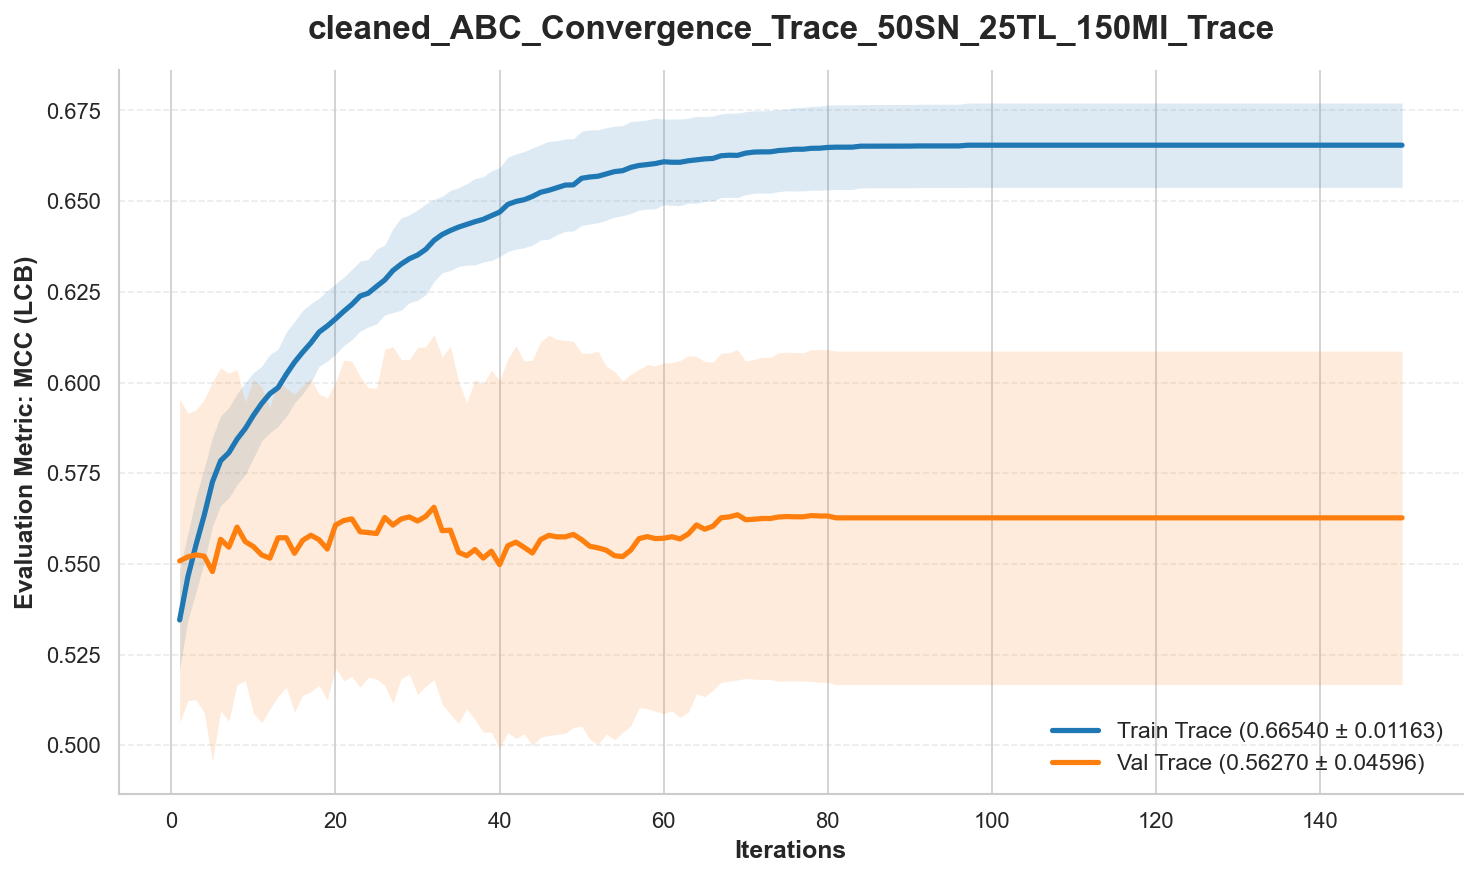

In [8]:
process_and_plot_traces("../Trace History")